# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 10 — Asset-Class Strategy Attribution & Specialisation

**Purpose:** determine whether different strategy architectures are better suited to different asset classes.

This notebook addresses the hypothesis:

> **Dual Trend may be unusually strong in rates, while SuperbCommand may be comparatively stronger in equities, crypto, or other asset classes.**

Notebook 10 is primarily a **diagnostic attribution notebook**, not a final allocation optimiser.

### Strategies compared

For each instrument and each asset class, compare:

1. **SuperbCommand CORE**
2. **SuperbCommand PT_REDUCE_25**
3. **Dual Trend 13/52**
4. **TSMOM 52W**
5. **Passive Long**

All comparisons use the same underlying prototype universe already defined upstream.

### Key research questions

- Which strategy has the highest Sharpe by asset class?
- Does the ranking change when using Sortino, Calmar, CAGR, or drawdown?
- Is Dual Trend's portfolio-level strength concentrated in rates?
- Does SuperbCommand outperform within equities or crypto?
- Are results broad across instruments, or driven by one proxy?
- Are strategy rankings stable across subperiods?
- Do different strategies dominate in different historical stress regimes?

### Important anti-overfitting rule

Notebook 10 does **not** automatically assign a winning strategy to each asset class.

Any apparent specialisation discovered here must later be tested through a sequential walk-forward asset-class selector.

### Final holdout discipline

Research sample ends:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 10.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}

RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 10 cannot run with the 2026 holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
SC_STRATEGY_PATH = PATHS["data_processed"] / "04_strategy_return_panel.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

for p in [SIGNAL_PATH, SC_STRATEGY_PATH, META_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 10.2 — LOAD UPSTREAM DATA
# ============================================================
panel = pd.read_parquet(SIGNAL_PATH)
sc_strategy_returns = pd.read_parquet(SC_STRATEGY_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

try:
    panel = panel.reorder_levels(["date", "ticker"]).sort_index()
except Exception:
    panel = panel.sort_index()

if panel.index.get_level_values("date").max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected in signal panel.")

if sc_strategy_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected in strategy return panel.")

tickers = sorted(meta.index.tolist())
asset_classes = sorted(meta["asset_class"].unique().tolist())

print("Markets:", len(tickers))
print("Asset classes:", asset_classes)


Markets: 11
Asset classes: ['commodities', 'crypto', 'equities', 'fx', 'rates']


## 10.3 Build instrument-level benchmark returns

The benchmark strategies are recreated at the individual-instrument level so that every market can be compared directly.

### Passive Long

\[
s_t = 1
\]

### TSMOM 52W

\[
s_t =
\begin{cases}
1,& R_{52w,t-1}>0\\
0,& \text{otherwise}
\end{cases}
\]

### Dual Trend 13/52

\[
s_t
=
\frac{
\mathbf{1}(R_{13w,t-1}>0)
+
\mathbf{1}(R_{52w,t-1}>0)
}{2}
\]

This yields exposures of:

- 0.0
- 0.5
- 1.0

All benchmark signals use a one-week lag.


In [3]:
# ============================================================
# 10.3 — UNDERLYING RETURNS & BENCHMARK SIGNALS
# ============================================================
close = pd.concat(
    {
        t: panel.xs(t, level="ticker")["close"]
        for t in tickers
    },
    axis=1
).sort_index()

underlying_returns = close.pct_change(fill_method=None)

ret_13 = close.pct_change(13, fill_method=None).shift(1)
ret_52 = close.pct_change(52, fill_method=None).shift(1)

passive_signal = pd.DataFrame(1.0, index=close.index, columns=close.columns)

tsmom_signal = (ret_52 > 0).astype(float)
tsmom_signal = tsmom_signal.where(ret_52.notna())

dual_signal = (
    (ret_13 > 0).astype(float)
    + (ret_52 > 0).astype(float)
) / 2.0
dual_signal = dual_signal.where(
    ret_13.notna() & ret_52.notna()
)

benchmark_returns = {
    "PASSIVE_LONG": passive_signal * underlying_returns,
    "TSMOM_52W": tsmom_signal * underlying_returns,
    "DUAL_TREND_13_52": dual_signal * underlying_returns,
}

print("Instrument-level benchmark returns built.")


Instrument-level benchmark returns built.


## 10.4 Extract instrument-level SuperbCommand returns

Notebook 04 already calculated the market-level long/cash returns with:

- one-week signal lag;
- market-level transaction costs;
- the relevant SuperbCommand exposure logic.

Notebook 10 carries forward:

- `CORE`
- `PT_REDUCE_25`


In [4]:
# ============================================================
# 10.4 — EXTRACT SUPERBCOMMAND MARKET RETURNS
# ============================================================
STRATEGIES = [
    "SC_CORE",
    "SC_PT_REDUCE_25",
    "DUAL_TREND_13_52",
    "TSMOM_52W",
    "PASSIVE_LONG",
]

market_strategy_returns = {}

for ticker in tickers:
    d = pd.DataFrame(index=underlying_returns.index)

    core_key = (ticker, "CORE", "long_cash")
    pt_key = (ticker, "PT_REDUCE_25", "long_cash")

    if core_key not in sc_strategy_returns.columns:
        raise KeyError(f"Missing market strategy return: {core_key}")
    if pt_key not in sc_strategy_returns.columns:
        raise KeyError(f"Missing market strategy return: {pt_key}")

    d["SC_CORE"] = sc_strategy_returns[core_key]
    d["SC_PT_REDUCE_25"] = sc_strategy_returns[pt_key]
    d["DUAL_TREND_13_52"] = benchmark_returns["DUAL_TREND_13_52"][ticker]
    d["TSMOM_52W"] = benchmark_returns["TSMOM_52W"][ticker]
    d["PASSIVE_LONG"] = benchmark_returns["PASSIVE_LONG"][ticker]

    market_strategy_returns[ticker] = d.loc[:RESEARCH_END]

print("Market strategy panels:", len(market_strategy_returns))


Market strategy panels: 11


## 10.5 Performance functions


In [5]:
# ============================================================
# 10.5 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 10.6 Instrument-level strategy league table

This is the most granular attribution table.

For every ticker, calculate the performance of all five strategy definitions.


In [6]:
# ============================================================
# 10.6 — INSTRUMENT-LEVEL PERFORMANCE
# ============================================================
instrument_rows = []

for ticker, df in market_strategy_returns.items():
    for strategy in STRATEGIES:
        m = metrics(df[strategy])

        instrument_rows.append({
            "ticker": ticker,
            "asset_class": meta.loc[ticker, "asset_class"],
            "market_name": meta.loc[ticker, "market_name"],
            "strategy": strategy,
            **m,
        })

instrument_performance = pd.DataFrame(instrument_rows)

display(
    instrument_performance.sort_values(
        ["ticker", "sharpe"],
        ascending=[True, False]
    )
)


,ticker,asset_class,market_name,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
2,BTC-USD,crypto,Bitcoin,DUAL_TREND_13_52,536,0.674245,0.573191,1.181032,1.705763,-0.637080,1.058337,0.509658,-0.390115,0.496269
1,BTC-USD,crypto,Bitcoin,SC_PT_REDUCE_25,589,0.628994,0.567653,1.138488,1.550011,-0.674561,0.932450,0.509658,-0.390115,0.376910
3,BTC-USD,crypto,Bitcoin,TSMOM_52W,536,0.651730,0.611328,1.122001,1.597809,-0.748688,0.870496,0.509658,-0.390115,0.438433
0,BTC-USD,crypto,Bitcoin,SC_CORE,589,0.615366,0.574115,1.118090,1.501108,-0.656423,0.937453,0.509658,-0.390115,0.376910
4,BTC-USD,crypto,Bitcoin,PASSIVE_LONG,588,0.611944,0.670579,1.044513,1.637507,-0.816880,0.749123,0.509658,-0.390115,0.547619
7,DBC,commodities,Broad Commodities,DUAL_TREND_13_52,985,0.035881,0.122729,0.348731,0.383849,-0.359298,0.099863,0.150831,-0.103448,0.368528
8,DBC,commodities,Broad Commodities,TSMOM_52W,985,0.023239,0.138963,0.235225,0.225502,-0.517180,0.044934,0.150831,-0.131152,0.270051
9,DBC,commodities,Broad Commodities,PASSIVE_LONG,1037,0.010630,0.190112,0.151241,0.209003,-0.759020,0.014005,0.150831,-0.131152,0.522662
6,DBC,commodities,Broad Commodities,SC_PT_REDUCE_25,1038,-0.015145,0.154952,-0.020315,-0.022246,-0.689165,-0.021977,0.150831,-0.131152,0.354528
5,DBC,commodities,Broad Commodities,SC_CORE,1038,-0.016513,0.157082,-0.026746,-0.029354,-0.694304,-0.023784,0.150831,-0.131152,0.354528


## 10.7 Best strategy by instrument

Rank strategies within each market by:

1. Sharpe
2. Sortino
3. Calmar

These are diagnostics only; they are not yet portfolio assignments.


In [7]:
# ============================================================
# 10.7 — BEST STRATEGY BY MARKET
# ============================================================
best_by_market = (
    instrument_performance
    .sort_values(
        ["ticker", "sharpe", "sortino", "calmar"],
        ascending=[True, False, False, False]
    )
    .groupby("ticker", as_index=False)
    .first()
)

display(
    best_by_market[
        [
            "ticker",
            "asset_class",
            "market_name",
            "strategy",
            "cagr",
            "sharpe",
            "sortino",
            "max_drawdown",
            "calmar",
        ]
    ]
)


,ticker,asset_class,market_name,strategy,cagr,sharpe,sortino,max_drawdown,calmar
0,BTC-USD,crypto,Bitcoin,DUAL_TREND_13_52,0.674245,1.181032,1.705763,-0.637080,1.058337
1,DBC,commodities,Broad Commodities,DUAL_TREND_13_52,0.035881,0.348731,0.383849,-0.359298,0.099863
2,EEM,equities,Emerging-Market Equities,PASSIVE_LONG,0.067162,0.394584,0.553398,-0.626301,0.107236
3,EFA,equities,Developed ex-US Equities,SC_CORE,0.056898,0.457816,0.502946,-0.331486,0.171644
4,GLD,commodities,Gold,PASSIVE_LONG,0.115450,0.730396,1.059745,-0.447446,0.258019
5,IEF,rates,US Treasury 7-10Y,DUAL_TREND_13_52,0.030923,0.648354,0.873895,-0.081582,0.379038
6,SHY,rates,US Treasury 1-3Y,TSMOM_52W,0.020481,1.692231,2.431990,-0.019038,1.075827
7,SPY,equities,US Large-Cap Equities,SC_CORE,0.107508,0.792460,0.887717,-0.318290,0.337769
8,TIP,rates,US Inflation-Linked Treasuries,PASSIVE_LONG,0.033772,0.583043,0.732239,-0.142208,0.237479
9,TLT,rates,US Treasury 20Y+,PASSIVE_LONG,0.032293,0.298830,0.456476,-0.478267,0.067521


## 10.8 Strategy win counts by asset class

This asks whether specific strategies repeatedly win inside specific asset classes.


In [8]:
# ============================================================
# 10.8 — WIN COUNTS BY ASSET CLASS
# ============================================================
win_counts = (
    best_by_market
    .groupby(["asset_class", "strategy"])
    .size()
    .rename("markets_won")
    .reset_index()
)

display(win_counts)


,asset_class,strategy,markets_won
0,commodities,DUAL_TREND_13_52,1
1,commodities,PASSIVE_LONG,1
2,crypto,DUAL_TREND_13_52,1
3,equities,PASSIVE_LONG,1
4,equities,SC_CORE,2
5,fx,DUAL_TREND_13_52,1
6,rates,DUAL_TREND_13_52,1
7,rates,PASSIVE_LONG,2
8,rates,TSMOM_52W,1


## 10.9 Asset-class equal-weight strategy returns

To avoid letting an asset class with more instruments automatically dominate the comparison, Notebook 10 builds an **equal-weight within-class return series** for each strategy.

For asset class \(c\):

\[
R_{c,t}^{strategy}
=
\frac{1}{N_c}
\sum_{i \in c}
R_{i,t}^{strategy}
\]

This is a diagnostic attribution portfolio, not the final portfolio weighting method.


In [9]:
# ============================================================
# 10.9 — BUILD ASSET-CLASS STRATEGY RETURNS
# ============================================================
asset_class_strategy_returns = {}

for asset_class in asset_classes:
    members = meta.index[meta["asset_class"] == asset_class].tolist()

    for strategy in STRATEGIES:
        series_list = [
            market_strategy_returns[t][strategy].rename(t)
            for t in members
        ]

        mat = pd.concat(series_list, axis=1)

        # Equal-weight available markets within the class.
        class_return = mat.mean(axis=1, skipna=True)

        asset_class_strategy_returns[(asset_class, strategy)] = class_return

asset_class_return_panel = pd.concat(
    asset_class_strategy_returns,
    axis=1
)

asset_class_return_panel.columns = pd.MultiIndex.from_tuples(
    asset_class_return_panel.columns,
    names=["asset_class", "strategy"],
)

display(asset_class_return_panel.tail())


asset_class commodities                                             \
strategy        SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                 
2025-11-28     0.029944        0.029944         0.029944  0.029944   
2025-12-05     0.003998        0.003998         0.003998  0.003998   
2025-12-12     0.002858        0.002858         0.002858  0.002858   
2025-12-19     0.003000        0.003000         0.003000  0.003000   
2025-12-26     0.035640        0.035640         0.035640  0.035640   

asset_class                 crypto                                             \
strategy    PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                            
2025-11-28      0.029944  0.068498        0.068498              0.0       0.0   
2025-12-05      0.003998 -0.016845       -0.016845              0.0       0.0   
2025-12-12      0.002858  0.009874        0.009874              0.0       0.0   
2025-12-19      0.003000 -0.024006       -0.024006              0.0       0.0   
2025-12-26      0.035640 -0.009102       -0.009102              0.0       0.0   

asset_class               ...        fx                                   \
strategy    PASSIVE_LONG  ...   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                      ...                                              
2025-11-28      0.068498  ... -0.006640       -0.006640        -0.003170   
2025-12-05     -0.016845  ... -0.004608       -0.004608        -0.002304   
2025-12-12      0.009874  ... -0.004630       -0.004630        -0.002315   
2025-12-19     -0.024006  ...  0.004293        0.004293         0.002147   
2025-12-26     -0.009102  ... -0.006374       -0.006374        -0.003187   

asset_class                            rates                                   \
strategy    TSMOM_52W PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                                                                            
2025-11-28        0.0    -0.006340  0.003472        0.003299         0.003472   
2025-12-05        0.0    -0.004608 -0.007973       -0.007652        -0.007973   
2025-12-12        0.0    -0.004630 -0.003275       -0.003226        -0.001849   
2025-12-19        0.0     0.004293  0.003072        0.002520         0.002225   
2025-12-26        0.0    -0.006374  0.001403        0.001081         0.001007   

asset_class                         
strategy    TSMOM_52W PASSIVE_LONG  
date                                
2025-11-28   0.003472     0.003472  
2025-12-05  -0.007973    -0.007973  
2025-12-12  -0.000921    -0.003275  
2025-12-19   0.003072     0.003072  
2025-12-26   0.001403     0.001403  

[5 rows x 25 columns]

## 10.10 Asset-class performance league table


In [10]:
# ============================================================
# 10.10 — ASSET-CLASS PERFORMANCE
# ============================================================
asset_class_rows = []

for (asset_class, strategy), r in asset_class_strategy_returns.items():
    m = metrics(r)

    asset_class_rows.append({
        "asset_class": asset_class,
        "strategy": strategy,
        **m,
    })

asset_class_performance = pd.DataFrame(asset_class_rows)

display(
    asset_class_performance.sort_values(
        ["asset_class", "sharpe"],
        ascending=[True, False]
    )
)


,asset_class,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
2,commodities,DUAL_TREND_13_52,1042,0.065568,0.111831,0.624328,0.759302,-0.253550,0.258599,0.095608,-0.094061,0.506718
4,commodities,PASSIVE_LONG,1094,0.073333,0.150270,0.546738,0.743969,-0.511926,0.143250,0.098041,-0.094061,0.561243
3,commodities,TSMOM_52W,1042,0.060094,0.124040,0.533028,0.614386,-0.359804,0.167019,0.095608,-0.094061,0.450096
1,commodities,SC_PT_REDUCE_25,1095,0.029067,0.120211,0.298823,0.362603,-0.423843,0.068579,0.095608,-0.092069,0.440183
0,commodities,SC_CORE,1095,0.028663,0.122265,0.292626,0.356341,-0.431818,0.066377,0.095608,-0.092069,0.443836
7,crypto,DUAL_TREND_13_52,536,0.674245,0.573191,1.181032,1.705763,-0.637080,1.058337,0.509658,-0.390115,0.496269
6,crypto,SC_PT_REDUCE_25,589,0.628994,0.567653,1.138488,1.550011,-0.674561,0.932450,0.509658,-0.390115,0.376910
8,crypto,TSMOM_52W,536,0.651730,0.611328,1.122001,1.597809,-0.748688,0.870496,0.509658,-0.390115,0.438433
5,crypto,SC_CORE,589,0.615366,0.574115,1.118090,1.501108,-0.656423,0.937453,0.509658,-0.390115,0.376910
9,crypto,PASSIVE_LONG,588,0.611944,0.670579,1.044513,1.637507,-0.816880,0.749123,0.509658,-0.390115,0.547619


## 10.11 Best strategy by asset class

This is the key table for the user's hypothesis.

It identifies the in-sample research winner by asset class, while explicitly avoiding treating that winner as a final assignment.


In [11]:
# ============================================================
# 10.11 — BEST STRATEGY BY ASSET CLASS
# ============================================================
best_by_asset_class = (
    asset_class_performance
    .sort_values(
        ["asset_class", "sharpe", "sortino", "calmar"],
        ascending=[True, False, False, False]
    )
    .groupby("asset_class", as_index=False)
    .first()
)

display(best_by_asset_class)


,asset_class,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,commodities,DUAL_TREND_13_52,1042,0.065568,0.111831,0.624328,0.759302,-0.253550,0.258599,0.095608,-0.094061,0.506718
1,crypto,DUAL_TREND_13_52,536,0.674245,0.573191,1.181032,1.705763,-0.637080,1.058337,0.509658,-0.390115,0.496269
2,equities,SC_CORE,1095,0.070342,0.139085,0.559097,0.656531,-0.319397,0.220234,0.098182,-0.129492,0.450228
3,fx,DUAL_TREND_13_52,930,0.011889,0.055955,0.239225,0.281250,-0.176217,0.067469,0.057435,-0.045698,0.381720
4,rates,DUAL_TREND_13_52,1042,0.024944,0.046694,0.551097,0.731760,-0.086156,0.289518,0.032811,-0.042512,0.532630


## 10.12 Strategy-ranking matrix

This produces an intuitive Sharpe matrix:

\[
\text{Asset Class} \times \text{Strategy}
\]

Useful patterns might include:

- rates strongly favouring Dual Trend;
- equities favouring SuperbCommand;
- crypto favouring SuperbCommand;
- commodities favouring conventional trend;
- FX favouring one or neither.


strategy,DUAL_TREND_13_52,PASSIVE_LONG,SC_CORE,SC_PT_REDUCE_25,TSMOM_52W
asset_class,,,,,
commodities,0.624328,0.546738,0.292626,0.298823,0.533028
crypto,1.181032,1.044513,1.118090,1.138488,1.122001
equities,0.522135,0.506565,0.559097,0.552039,0.478539
fx,0.239225,0.225843,0.148742,0.153424,0.114660
rates,0.551097,0.517529,0.454774,0.452990,0.477327


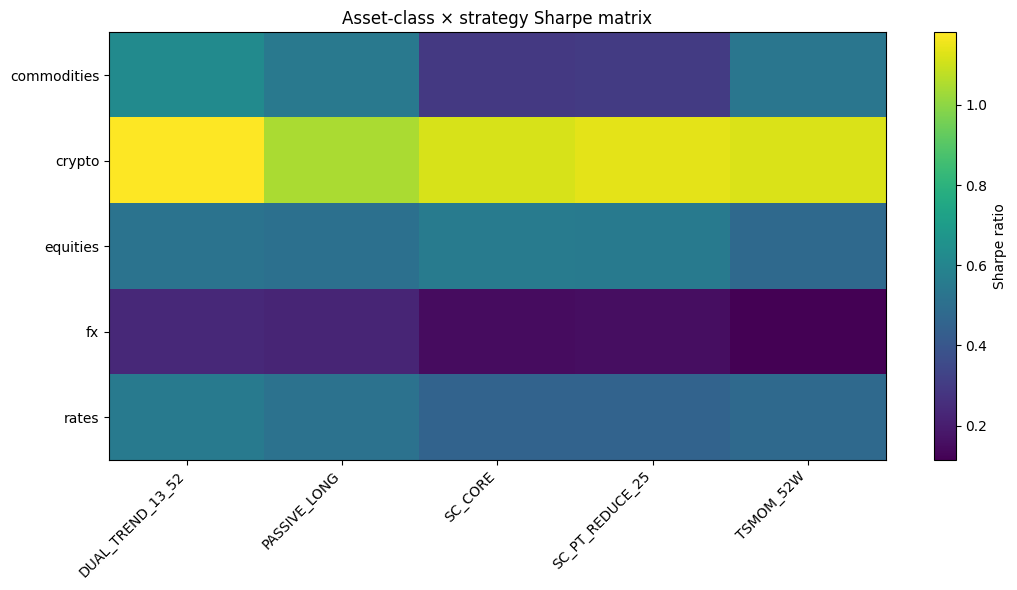

In [12]:
# ============================================================
# 10.12 — SHARPE MATRIX
# ============================================================
sharpe_matrix = asset_class_performance.pivot(
    index="asset_class",
    columns="strategy",
    values="sharpe",
)

display(sharpe_matrix)

plt.figure(figsize=(11, 6))
plt.imshow(sharpe_matrix.values, aspect="auto")
plt.xticks(
    range(len(sharpe_matrix.columns)),
    sharpe_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(sharpe_matrix.index)),
    sharpe_matrix.index
)
plt.colorbar(label="Sharpe ratio")
plt.title("Asset-class × strategy Sharpe matrix")
plt.tight_layout()
plt.show()


## 10.13 Relative edge versus Dual Trend

Because Dual Trend is the strongest broad benchmark, calculate:

\[
\Delta Sharpe
=
Sharpe_{strategy}
-
Sharpe_{DualTrend}
\]

within each asset class.


In [13]:
# ============================================================
# 10.13 — DELTAS VS DUAL TREND BY ASSET CLASS
# ============================================================
dual_ref = (
    asset_class_performance[
        asset_class_performance["strategy"] == "DUAL_TREND_13_52"
    ]
    .set_index("asset_class")
)

delta_rows = []

for _, row in asset_class_performance.iterrows():
    asset_class = row["asset_class"]
    ref = dual_ref.loc[asset_class]

    delta_rows.append({
        "asset_class": asset_class,
        "strategy": row["strategy"],
        "delta_cagr_vs_dual": row["cagr"] - ref["cagr"],
        "delta_sharpe_vs_dual": row["sharpe"] - ref["sharpe"],
        "delta_sortino_vs_dual": row["sortino"] - ref["sortino"],
        "delta_max_drawdown_vs_dual": row["max_drawdown"] - ref["max_drawdown"],
        "delta_calmar_vs_dual": row["calmar"] - ref["calmar"],
    })

asset_class_deltas = pd.DataFrame(delta_rows)

display(
    asset_class_deltas.sort_values(
        ["asset_class", "delta_sharpe_vs_dual"],
        ascending=[True, False]
    )
)


,asset_class,strategy,delta_cagr_vs_dual,delta_sharpe_vs_dual,delta_sortino_vs_dual,delta_max_drawdown_vs_dual,delta_calmar_vs_dual
2,commodities,DUAL_TREND_13_52,0.000000,0.000000,0.000000,0.000000,0.000000
4,commodities,PASSIVE_LONG,0.007766,-0.077589,-0.015332,-0.258377,-0.115349
3,commodities,TSMOM_52W,-0.005473,-0.091300,-0.144916,-0.106254,-0.091580
1,commodities,SC_PT_REDUCE_25,-0.036501,-0.325505,-0.396699,-0.170293,-0.190020
0,commodities,SC_CORE,-0.036905,-0.331701,-0.402960,-0.178269,-0.192221
7,crypto,DUAL_TREND_13_52,0.000000,0.000000,0.000000,0.000000,0.000000
6,crypto,SC_PT_REDUCE_25,-0.045251,-0.042545,-0.155752,-0.037482,-0.125887
8,crypto,TSMOM_52W,-0.022515,-0.059031,-0.107954,-0.111609,-0.187842
5,crypto,SC_CORE,-0.058880,-0.062943,-0.204655,-0.019343,-0.120884
9,crypto,PASSIVE_LONG,-0.062301,-0.136519,-0.068256,-0.179801,-0.309214


## 10.14 Subperiod stability by asset class

The full research sample is split into:

- 2006–2011
- 2012–2017
- 2018–2025

This asks whether an apparent asset-class winner is persistent or merely regime-specific.


In [14]:
# ============================================================
# 10.14 — SUBPERIOD ASSET-CLASS PERFORMANCE
# ============================================================
SUBPERIODS = {
    "2006-2011": ("2006-01-01", "2011-12-31"),
    "2012-2017": ("2012-01-01", "2017-12-31"),
    "2018-2025": ("2018-01-01", "2025-12-31"),
}

subperiod_rows = []

for period, (start, end) in SUBPERIODS.items():
    for (asset_class, strategy), r in asset_class_strategy_returns.items():
        x = r.loc[start:end].dropna()
        m = metrics(x)

        subperiod_rows.append({
            "period": period,
            "asset_class": asset_class,
            "strategy": strategy,
            **m,
        })

subperiod_performance = pd.DataFrame(subperiod_rows)

display(
    subperiod_performance.sort_values(
        ["period", "asset_class", "sharpe"],
        ascending=[True, True, False]
    )
)


,period,asset_class,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
2,2006-2011,commodities,DUAL_TREND_13_52,312,0.117701,0.160434,0.775133,0.963018,-0.253550,0.464212,0.062185,-0.094061,0.589744
4,2006-2011,commodities,PASSIVE_LONG,313,0.125792,0.197963,0.698920,0.922131,-0.413659,0.304096,0.098041,-0.094061,0.597444
3,2006-2011,commodities,TSMOM_52W,312,0.096521,0.182749,0.596805,0.741130,-0.359804,0.268259,0.070631,-0.094061,0.576923
1,2006-2011,commodities,SC_PT_REDUCE_25,313,0.010677,0.145007,0.146517,0.154104,-0.423843,0.025191,0.070631,-0.088949,0.386581
0,2006-2011,commodities,SC_CORE,313,0.007400,0.147438,0.124507,0.131873,-0.431818,0.017138,0.070631,-0.088949,0.386581
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2018-2025,rates,DUAL_TREND_13_52,417,0.011866,0.043767,0.291429,0.328288,-0.086156,0.137722,0.032811,-0.042512,0.494005
73,2018-2025,rates,TSMOM_52W,417,0.010846,0.044772,0.263355,0.278677,-0.105308,0.102989,0.032811,-0.042512,0.479616
70,2018-2025,rates,SC_CORE,417,0.012708,0.059150,0.243052,0.331234,-0.209265,0.060726,0.032811,-0.042512,0.517986
71,2018-2025,rates,SC_PT_REDUCE_25,417,0.012496,0.058492,0.241551,0.330288,-0.208629,0.059897,0.032811,-0.042512,0.517986


## 10.15 Subperiod winner stability

Count how often each strategy ranks first within each asset class across the three broad historical eras.


In [15]:
# ============================================================
# 10.15 — SUBPERIOD WIN COUNTS
# ============================================================
subperiod_winners = (
    subperiod_performance
    .sort_values(
        ["period", "asset_class", "sharpe", "sortino", "calmar"],
        ascending=[True, True, False, False, False]
    )
    .groupby(["period", "asset_class"], as_index=False)
    .first()
)

subperiod_win_counts = (
    subperiod_winners
    .groupby(["asset_class", "strategy"])
    .size()
    .rename("subperiods_won")
    .reset_index()
)

display(subperiod_win_counts)


,asset_class,strategy,subperiods_won
0,commodities,DUAL_TREND_13_52,2
1,commodities,SC_CORE,1
2,crypto,DUAL_TREND_13_52,1
3,crypto,SC_CORE,1
4,crypto,SC_PT_REDUCE_25,1
5,equities,DUAL_TREND_13_52,2
6,equities,SC_CORE,1
7,fx,DUAL_TREND_13_52,1
8,fx,PASSIVE_LONG,1
9,fx,TSMOM_52W,1


## 10.16 Rolling 5-year Sharpe by asset class

This helps visualise strategy leadership through time.

One chart is generated per asset class.


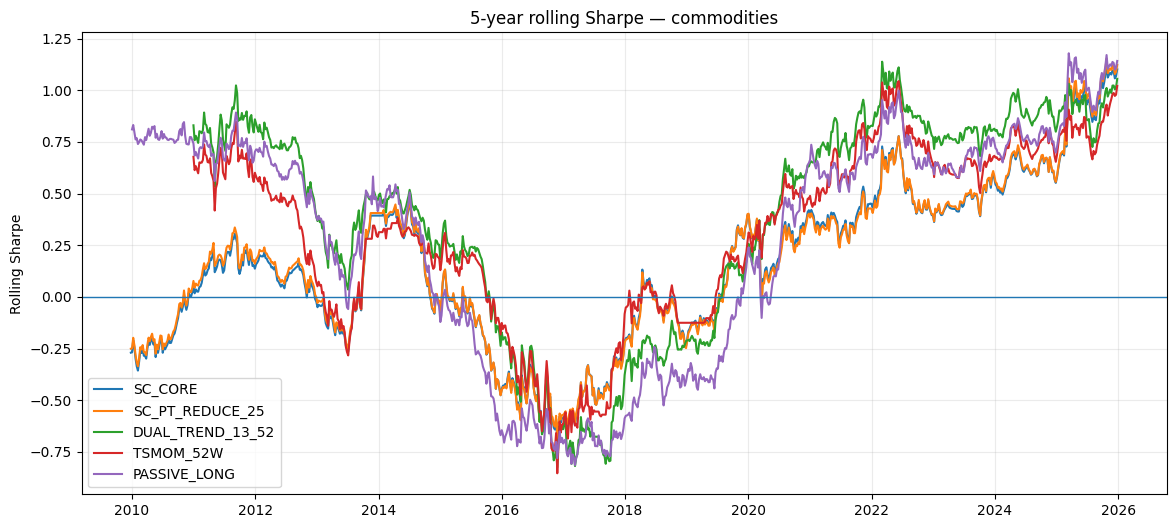

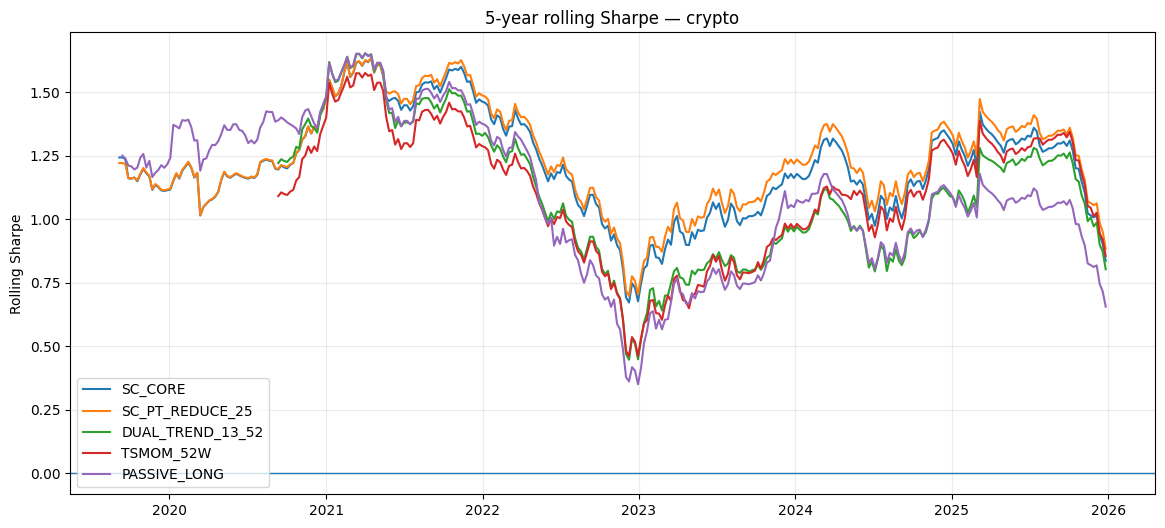

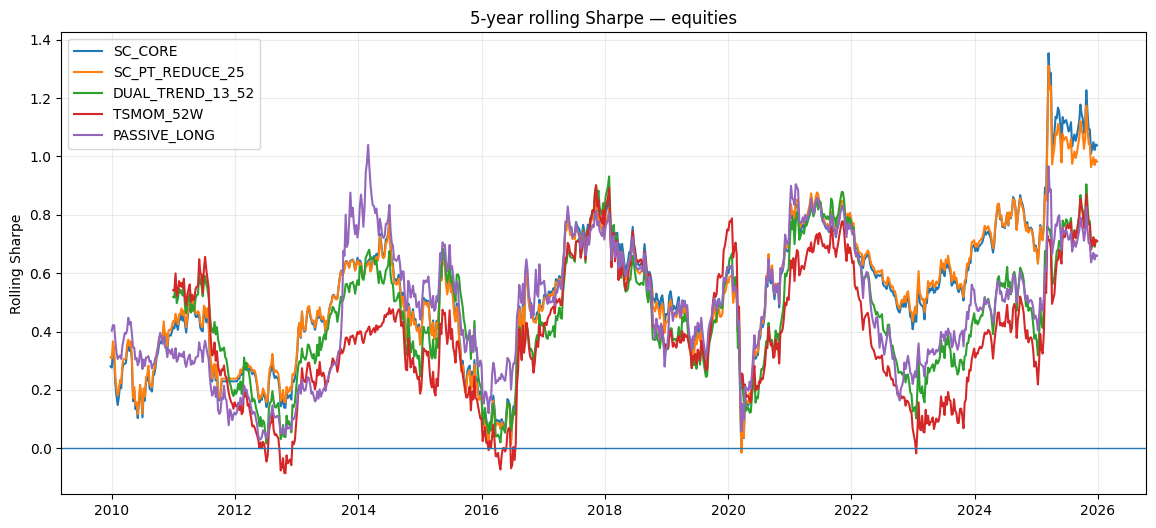

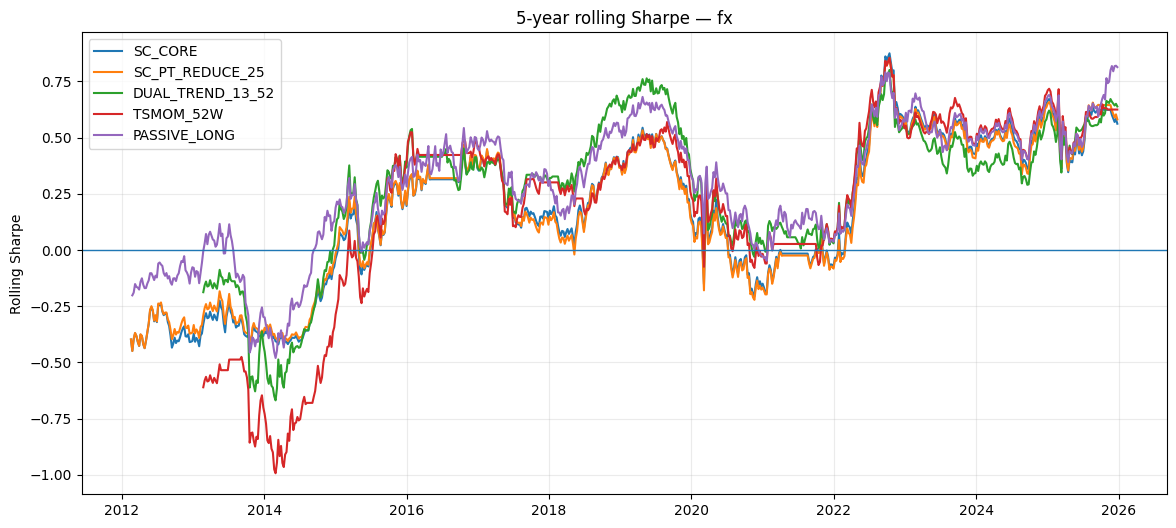

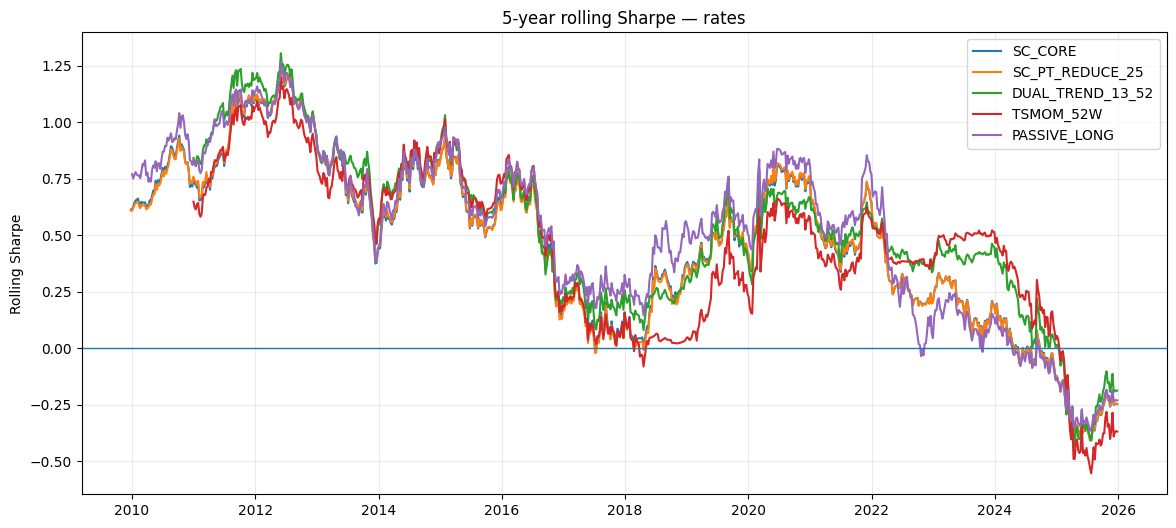

In [16]:
# ============================================================
# 10.16 — ROLLING SHARPE BY ASSET CLASS
# ============================================================
ROLL_WEEKS = 5 * 52

def rolling_sharpe(r, window=ROLL_WEEKS):
    mean = r.rolling(window, min_periods=window).mean()
    vol = r.rolling(window, min_periods=window).std(ddof=1)
    return mean / vol.replace(0, np.nan) * np.sqrt(WEEKS_PER_YEAR)

for asset_class in asset_classes:
    plt.figure(figsize=(14, 6))

    for strategy in STRATEGIES:
        r = asset_class_strategy_returns[(asset_class, strategy)]
        rs = rolling_sharpe(r)
        plt.plot(rs.index, rs.values, label=strategy)

    plt.axhline(0, linewidth=1)
    plt.title(f"5-year rolling Sharpe — {asset_class}")
    plt.ylabel("Rolling Sharpe")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 10.17 Stress-period behaviour by asset class

This asks whether strategy specialisation becomes particularly visible in crisis regimes.


In [17]:
# ============================================================
# 10.17 — ASSET-CLASS STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for (asset_class, strategy), r in asset_class_strategy_returns.items():
        x = r.loc[start:end].dropna()

        if len(x) == 0:
            continue

        stress_rows.append({
            "period": period,
            "asset_class": asset_class,
            "strategy": strategy,
            "weeks": len(x),
            "total_return": (1 + x).prod() - 1,
            "max_drawdown": max_drawdown(x),
            "worst_week": x.min(),
        })

stress = pd.DataFrame(stress_rows)

display(
    stress.sort_values(
        ["period", "asset_class", "total_return"],
        ascending=[True, True, False]
    )
)


,period,asset_class,strategy,weeks,total_return,max_drawdown,worst_week
69,2022 inflation/rates shock,commodities,PASSIVE_LONG,52,0.095262,-0.164393,-0.035500
66,2022 inflation/rates shock,commodities,SC_PT_REDUCE_25,52,0.092323,-0.157497,-0.035500
65,2022 inflation/rates shock,commodities,SC_CORE,52,0.080859,-0.164393,-0.035500
67,2022 inflation/rates shock,commodities,DUAL_TREND_13_52,52,0.064116,-0.118234,-0.027092
68,2022 inflation/rates shock,commodities,TSMOM_52W,52,0.045787,-0.144326,-0.030957
...,...,...,...,...,...,...,...
19,Global Financial Crisis,rates,PASSIVE_LONG,91,0.216931,-0.063049,-0.026365
18,Global Financial Crisis,rates,TSMOM_52W,91,0.182068,-0.062250,-0.026365
15,Global Financial Crisis,rates,SC_CORE,91,0.179444,-0.055890,-0.026365
16,Global Financial Crisis,rates,SC_PT_REDUCE_25,91,0.175786,-0.055138,-0.026365


## 10.18 Cross-sectional consistency within asset class

A strategy may appear to win an asset class because one proxy is exceptional.

This section measures, for each asset class and strategy:

- mean instrument Sharpe;
- median instrument Sharpe;
- share of instruments with Sharpe > 0;
- share of instruments where strategy beats Dual Trend Sharpe.


In [18]:
# ============================================================
# 10.18 — WITHIN-CLASS CROSS-SECTIONAL CONSISTENCY
# ============================================================
cross_rows = []

dual_inst = (
    instrument_performance[
        instrument_performance["strategy"] == "DUAL_TREND_13_52"
    ][["ticker", "sharpe"]]
    .rename(columns={"sharpe": "dual_sharpe"})
)

tmp = instrument_performance.merge(
    dual_inst,
    on="ticker",
    how="left"
)

for (asset_class, strategy), g in tmp.groupby(["asset_class", "strategy"]):
    cross_rows.append({
        "asset_class": asset_class,
        "strategy": strategy,
        "markets": len(g),
        "mean_instrument_sharpe": g["sharpe"].mean(),
        "median_instrument_sharpe": g["sharpe"].median(),
        "share_instruments_positive_sharpe": (g["sharpe"] > 0).mean(),
        "share_instruments_beating_dual": (g["sharpe"] > g["dual_sharpe"]).mean(),
    })

cross_sectional_consistency = pd.DataFrame(cross_rows)

display(
    cross_sectional_consistency.sort_values(
        ["asset_class", "mean_instrument_sharpe"],
        ascending=[True, False]
    )
)


,asset_class,strategy,markets,mean_instrument_sharpe,median_instrument_sharpe,share_instruments_positive_sharpe,share_instruments_beating_dual
0,commodities,DUAL_TREND_13_52,2,0.506234,0.506234,1.0,0.000000
1,commodities,PASSIVE_LONG,2,0.440818,0.440818,1.0,0.500000
4,commodities,TSMOM_52W,2,0.420360,0.420360,1.0,0.000000
3,commodities,SC_PT_REDUCE_25,2,0.250633,0.250633,0.5,0.000000
2,commodities,SC_CORE,2,0.245526,0.245526,0.5,0.000000
5,crypto,DUAL_TREND_13_52,1,1.181032,1.181032,1.0,0.000000
8,crypto,SC_PT_REDUCE_25,1,1.138488,1.138488,1.0,0.000000
9,crypto,TSMOM_52W,1,1.122001,1.122001,1.0,0.000000
7,crypto,SC_CORE,1,1.118090,1.118090,1.0,0.000000
6,crypto,PASSIVE_LONG,1,1.044513,1.044513,1.0,0.000000


## 10.19 Diagnostic specialisation scorecard

This combines several pieces of evidence without creating a final strategy assignment.

For each asset class and strategy, report:

- full-sample Sharpe rank;
- subperiod wins;
- instrument win count;
- cross-sectional mean Sharpe;
- share of instruments beating Dual Trend.

The goal is to identify plausible specialisation hypotheses for the next walk-forward notebook.


In [19]:
# ============================================================
# 10.19 — SPECIALISATION SCORECARD
# ============================================================
rank_df = asset_class_performance.copy()
rank_df["full_sample_sharpe_rank"] = (
    rank_df
    .groupby("asset_class")["sharpe"]
    .rank(method="min", ascending=False)
)

instrument_wins = (
    best_by_market
    .groupby(["asset_class", "strategy"])
    .size()
    .rename("instrument_wins")
    .reset_index()
)

scorecard = (
    rank_df[
        [
            "asset_class",
            "strategy",
            "sharpe",
            "sortino",
            "calmar",
            "full_sample_sharpe_rank",
        ]
    ]
    .merge(
        subperiod_win_counts,
        on=["asset_class", "strategy"],
        how="left",
    )
    .merge(
        instrument_wins,
        on=["asset_class", "strategy"],
        how="left",
    )
    .merge(
        cross_sectional_consistency,
        on=["asset_class", "strategy"],
        how="left",
    )
)

scorecard["subperiods_won"] = scorecard["subperiods_won"].fillna(0).astype(int)
scorecard["instrument_wins"] = scorecard["instrument_wins"].fillna(0).astype(int)

display(
    scorecard.sort_values(
        ["asset_class", "full_sample_sharpe_rank", "subperiods_won"],
        ascending=[True, True, False]
    )
)


,asset_class,strategy,sharpe,sortino,calmar,full_sample_sharpe_rank,subperiods_won,instrument_wins,markets,mean_instrument_sharpe,median_instrument_sharpe,share_instruments_positive_sharpe,share_instruments_beating_dual
2,commodities,DUAL_TREND_13_52,0.624328,0.759302,0.258599,1.0,2,1,2,0.506234,0.506234,1.0,0.000000
4,commodities,PASSIVE_LONG,0.546738,0.743969,0.143250,2.0,0,1,2,0.440818,0.440818,1.0,0.500000
3,commodities,TSMOM_52W,0.533028,0.614386,0.167019,3.0,0,0,2,0.420360,0.420360,1.0,0.000000
1,commodities,SC_PT_REDUCE_25,0.298823,0.362603,0.068579,4.0,0,0,2,0.250633,0.250633,0.5,0.000000
0,commodities,SC_CORE,0.292626,0.356341,0.066377,5.0,1,0,2,0.245526,0.245526,0.5,0.000000
7,crypto,DUAL_TREND_13_52,1.181032,1.705763,1.058337,1.0,1,1,1,1.181032,1.181032,1.0,0.000000
6,crypto,SC_PT_REDUCE_25,1.138488,1.550011,0.932450,2.0,1,0,1,1.138488,1.138488,1.0,0.000000
8,crypto,TSMOM_52W,1.122001,1.597809,0.870496,3.0,0,0,1,1.122001,1.122001,1.0,0.000000
5,crypto,SC_CORE,1.118090,1.501108,0.937453,4.0,1,0,1,1.118090,1.118090,1.0,0.000000
9,crypto,PASSIVE_LONG,1.044513,1.637507,0.749123,5.0,0,0,1,1.044513,1.044513,1.0,0.000000


## 10.20 Simple in-sample specialist portfolio — diagnostic only

For illustration only, create a portfolio that assigns each asset class its full-sample Sharpe winner.

This is **not** a valid final backtest because the assignment uses future information from the same research sample.

Its purpose is merely to estimate the potential economic importance of strategy specialisation.

The next notebook must recreate this idea sequentially.


In [20]:
# ============================================================
# 10.20 — DIAGNOSTIC SPECIALIST PORTFOLIO
# ============================================================
winner_map = dict(
    zip(
        best_by_asset_class["asset_class"],
        best_by_asset_class["strategy"],
    )
)

print("In-sample diagnostic winner map:")
display(pd.Series(winner_map, name="strategy").to_frame())

specialist_class_returns = {}

for asset_class in asset_classes:
    strategy = winner_map[asset_class]
    specialist_class_returns[asset_class] = asset_class_strategy_returns[
        (asset_class, strategy)
    ]

specialist_class_panel = pd.DataFrame(specialist_class_returns)

# Equal-weight asset classes for this purely diagnostic portfolio.
specialist_portfolio = specialist_class_panel.mean(axis=1, skipna=True)

specialist_metrics = pd.DataFrame(
    [{
        "strategy": "IN_SAMPLE_SPECIALIST_DIAGNOSTIC_ONLY",
        **metrics(specialist_portfolio),
    }]
)

display(specialist_metrics)


In-sample diagnostic winner map:


,strategy
commodities,DUAL_TREND_13_52
crypto,DUAL_TREND_13_52
equities,SC_CORE
fx,DUAL_TREND_13_52
rates,DUAL_TREND_13_52


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,IN_SAMPLE_SPECIALIST_DIAGNOSTIC_ONLY,1095,0.10929,0.096404,1.124882,1.504974,-0.162504,0.672536,0.100186,-0.112605,0.567123


## 10.21 Save outputs


In [21]:
# ============================================================
# 10.21 — SAVE OUTPUTS
# ============================================================
INSTRUMENT_PERF_PATH = PATHS["results"] / "10_instrument_strategy_performance.csv"
BEST_MARKET_PATH = PATHS["results"] / "10_best_strategy_by_market.csv"
WIN_COUNTS_PATH = PATHS["results"] / "10_strategy_win_counts_by_asset_class.csv"
ASSET_CLASS_PERF_PATH = PATHS["results"] / "10_asset_class_strategy_performance.csv"
BEST_ASSET_CLASS_PATH = PATHS["results"] / "10_best_strategy_by_asset_class.csv"
DELTAS_PATH = PATHS["results"] / "10_asset_class_deltas_vs_dualtrend.csv"
SUBPERIOD_PATH = PATHS["results"] / "10_asset_class_subperiod_performance.csv"
SUBPERIOD_WINS_PATH = PATHS["results"] / "10_asset_class_subperiod_wins.csv"
STRESS_PATH = PATHS["results"] / "10_asset_class_stress_summary.csv"
CROSS_PATH = PATHS["results"] / "10_cross_sectional_consistency.csv"
SCORECARD_PATH = PATHS["results"] / "10_specialisation_scorecard.csv"
SPECIALIST_PATH = PATHS["results"] / "10_diagnostic_specialist_portfolio.csv"

ASSET_CLASS_RETURNS_PATH = PATHS["data_processed"] / "10_asset_class_strategy_return_panel.parquet"
SPECIALIST_RETURNS_PATH = PATHS["data_processed"] / "10_diagnostic_specialist_return.parquet"

instrument_performance.to_csv(INSTRUMENT_PERF_PATH, index=False)
best_by_market.to_csv(BEST_MARKET_PATH, index=False)
win_counts.to_csv(WIN_COUNTS_PATH, index=False)
asset_class_performance.to_csv(ASSET_CLASS_PERF_PATH, index=False)
best_by_asset_class.to_csv(BEST_ASSET_CLASS_PATH, index=False)
asset_class_deltas.to_csv(DELTAS_PATH, index=False)
subperiod_performance.to_csv(SUBPERIOD_PATH, index=False)
subperiod_win_counts.to_csv(SUBPERIOD_WINS_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
cross_sectional_consistency.to_csv(CROSS_PATH, index=False)
scorecard.to_csv(SCORECARD_PATH, index=False)
specialist_metrics.to_csv(SPECIALIST_PATH, index=False)

asset_class_return_panel.to_parquet(ASSET_CLASS_RETURNS_PATH)
specialist_portfolio.to_frame("IN_SAMPLE_SPECIALIST_DIAGNOSTIC_ONLY").to_parquet(
    SPECIALIST_RETURNS_PATH
)

print("Saved Notebook 10 outputs.")


Saved Notebook 10 outputs.


## 10.22 Validation suite

Notebook 10 passes only if:

- 2026 remains absent;
- all five strategy definitions exist for every market;
- every asset class is represented;
- benchmark signals are lagged;
- no short exposure is introduced;
- diagnostic specialist assignment is clearly separated from valid OOS research;
- all outputs are written.


In [22]:
# ============================================================
# 10.22 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = panel.index.get_level_values("date").max() <= RESEARCH_END
checks["2026_absent"] = not (
    panel.index.get_level_values("date").year == 2026
).any()

checks["all_markets_have_all_strategies"] = (
    instrument_performance.groupby("ticker")["strategy"].nunique().eq(len(STRATEGIES)).all()
)

checks["all_asset_classes_present"] = (
    set(asset_class_performance["asset_class"]) == set(asset_classes)
)

checks["five_strategies_present"] = (
    set(asset_class_performance["strategy"]) == set(STRATEGIES)
)

checks["dual_signal_no_short"] = (
    dual_signal.dropna() >= 0
).all().all()

checks["tsmom_signal_no_short"] = (
    tsmom_signal.dropna() >= 0
).all().all()

checks["outputs_written"] = all(
    p.exists()
    for p in [
        INSTRUMENT_PERF_PATH,
        BEST_MARKET_PATH,
        WIN_COUNTS_PATH,
        ASSET_CLASS_PERF_PATH,
        BEST_ASSET_CLASS_PATH,
        DELTAS_PATH,
        SUBPERIOD_PATH,
        SUBPERIOD_WINS_PATH,
        STRESS_PATH,
        CROSS_PATH,
        SCORECARD_PATH,
        SPECIALIST_PATH,
        ASSET_CLASS_RETURNS_PATH,
        SPECIALIST_RETURNS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 10 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 10 STATUS: PASS")
print("=" * 78)
print("Asset-class strategy attribution completed.")
print("No final asset-class strategy assignments were made.")
print("Diagnostic specialist portfolio is in-sample only.")
print("2026 final holdout: NOT ACCESSED")
print("Next step should be sequential asset-class strategy selection.")


                          check  passed
                 holdout_absent    True
                    2026_absent    True
all_markets_have_all_strategies    True
      all_asset_classes_present    True
        five_strategies_present    True
           dual_signal_no_short    True
          tsmom_signal_no_short    True
                outputs_written    True

NOTEBOOK 10 STATUS: PASS
Asset-class strategy attribution completed.
No final asset-class strategy assignments were made.
Diagnostic specialist portfolio is in-sample only.
2026 final holdout: NOT ACCESSED
Next step should be sequential asset-class strategy selection.


In [23]:
# ============================================================
# 10.23 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "10",
    "notebook_name": "Asset-Class Strategy Attribution & Specialisation",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "strategies_compared": STRATEGIES,
    "asset_classes": asset_classes,
    "specialist_portfolio_status": "diagnostic_in_sample_only",
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "instrument_strategy_performance": str(INSTRUMENT_PERF_PATH),
        "best_strategy_by_market": str(BEST_MARKET_PATH),
        "strategy_win_counts_by_asset_class": str(WIN_COUNTS_PATH),
        "asset_class_strategy_performance": str(ASSET_CLASS_PERF_PATH),
        "best_strategy_by_asset_class": str(BEST_ASSET_CLASS_PATH),
        "asset_class_deltas_vs_dualtrend": str(DELTAS_PATH),
        "subperiod_performance": str(SUBPERIOD_PATH),
        "subperiod_wins": str(SUBPERIOD_WINS_PATH),
        "stress_summary": str(STRESS_PATH),
        "cross_sectional_consistency": str(CROSS_PATH),
        "specialisation_scorecard": str(SCORECARD_PATH),
        "diagnostic_specialist_portfolio": str(SPECIALIST_PATH),
        "asset_class_strategy_return_panel": str(ASSET_CLASS_RETURNS_PATH),
        "diagnostic_specialist_return": str(SPECIALIST_RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "10_asset_class_strategy_specialisation_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/10_asset_class_strategy_specialisation_manifest.json


---

# End of Notebook 10

## Main research question

\[
\boxed{\text{Which strategy architecture is best suited to each asset class?}}
\]

Notebook 10 decomposes the multi-asset result into:

- individual market performance;
- asset-class performance;
- subperiod stability;
- stress behaviour;
- cross-sectional consistency.

### Important

The in-sample specialist portfolio is **diagnostic only**.

Any apparent assignment such as:

- equities → SuperbCommand;
- rates → Dual Trend;
- crypto → SuperbCommand;

must be tested sequentially in a later walk-forward notebook before being considered valid.

### Final holdout

**2026 remains completely untouched.**
